# ChatEV: Predicción de la demanda de recarga de vehículos eléctricos mediante el procesamiento del lenguaje natural

### Trabajo Final – Modelado computacional, Simulación y Optimización. Máster en Ciencia de Datos

Autoras: Jimena Milla Moreno, Itsaso Ariztimuño Cenoz

Fuente:    https://github.com/IntelligentSystemsLab/ST-EVCDP

In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import T5ForConditionalGeneration, T5Tokenizer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import copy, random, warnings, math, json, re
from pathlib import Path
from scipy.spatial.distance import cdist
import glob
import os

warnings.filterwarnings("ignore")
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")
MODEL_NAME = "t5-small"

Dispositivo: cuda


## 1. Carga, Validación y Preprocesado del Dataset Real ST-EVCDP

In [4]:
from google.colab import drive
drive.mount('/content/drive')

ruta = "/content/drive/MyDrive/MASTER CD/2cuatri/Modelado computacional/Trabajo final/datasets"

dfs = {}

for fichero in glob.glob(os.path.join(ruta, "*.csv")):
    nombre = os.path.basename(fichero).replace(".csv", "")
    dfs[nombre] = pd.read_csv(fichero, index_col=0)

print(dfs.keys())

Mounted at /content/drive
dict_keys(['adj', 'distance', 'information', 'occupancy', 'duration', 'volume', 'price', 'time', 'stations'])


In [5]:
# Carga de datasets

REQUIRED_FILES = [
    "adj",
    "distance",
    "information",
    "occupancy",
    "duration",
    "volume",
    "price",
    "time"
]

def load_stevcdp(dfs: dict) -> dict:
    """ Carga los 8 ficheros CSV del dataset ST-EVCDP y retorna un dict con
    arrays ya alineados. Estructura esperada según §4.1.1 del paper:
    - 247 zonas de tráfico de Shenzhen
    - 30 días (19 jun – 18 jul 2022), intervalo 5 min → 8640 timesteps """

    print("\nCargando dataset ST-EVCDP desde dfs...")

    # Matriz de adyacencia
    adj = dfs["adj"].values.astype(np.float32)
    print(f"  adj.csv          → {adj.shape}")

    # Matriz de distancias
    dist = dfs["distance"].values.astype(np.float32)
    np.fill_diagonal(dist, 0.0)
    print(f"  distance.csv     → {dist.shape}")

    # Información estática
    info = dfs["information"].copy()

    info.columns = [
        c.strip().lower().replace(" ", "_")
        for c in info.columns
    ]

    print(f"  information.csv  → {info.shape}")
    print(f"     columnas: {list(info.columns)}")

    # Timestamps
    time_df = dfs["time"]

    try:
        timestamps = pd.to_datetime(time_df.iloc[:, 0])
    except:
        timestamps = pd.RangeIndex(len(time_df))

    n_timesteps = len(timestamps)

    print(f"  time.csv         → {n_timesteps} pasos")

    # Series temporales
    def load_ts(df):

        arr = df.values.astype(np.float32)

        n_zones = adj.shape[0]

        if arr.shape[0] == n_zones:
            return arr

        elif arr.shape[1] == n_zones:
            return arr.T

        else:
            raise ValueError(
                f"Shape {arr.shape} incompatible con {n_zones} zonas."
            )

    occupancy = load_ts(dfs["occupancy"]) # tasa [0,1]
    duration  = load_ts(dfs["duration"])  # horas
    volume    = load_ts(dfs["volume"])  # kWh
    price     = load_ts(dfs["price"]) # €/kWh

    n_zones = adj.shape[0]

    print(f"  occupancy.csv    → {occupancy.shape}")
    print(f"  duration.csv     → {duration.shape}")
    print(f"  volume.csv       → {volume.shape}")
    print(f"  price.csv        → {price.shape}")
    print(f"\nDataset: {n_zones} zonas × {n_timesteps} timesteps")

    return {
        "adj": adj,
        "dist": dist,
        "info": info,
        "timestamps": timestamps,
        "occupancy": occupancy,
        "duration": duration,
        "volume": volume,
        "price": price,
        "n_zones": n_zones,
        "n_timesteps": n_timesteps,
    }


Cargando dataset ST-EVCDP desde dfs...
  adj.csv          → (247, 247)
  distance.csv     → (247, 247)
  information.csv  → (247, 9)
     columnas: ['grid', 'count', 'fast_count', 'slow_count', 'area', 'lon', 'la', 'cbd', 'dynamic_pricing']
  time.csv         → 8640 pasos
  occupancy.csv    → (247, 8640)
  duration.csv     → (247, 8640)
  volume.csv       → (247, 8640)
  price.csv        → (247, 8640)

Dataset: 247 zonas × 8640 timesteps

 → Zonas totales: 247
 → Zonas vistas: 198
 → Zonas unseen: 49
 → Train t[0:5184] Val t[5184:6912] Test t[6912:8640]
[S1] EDA guardado en ChatEV_EDA.png


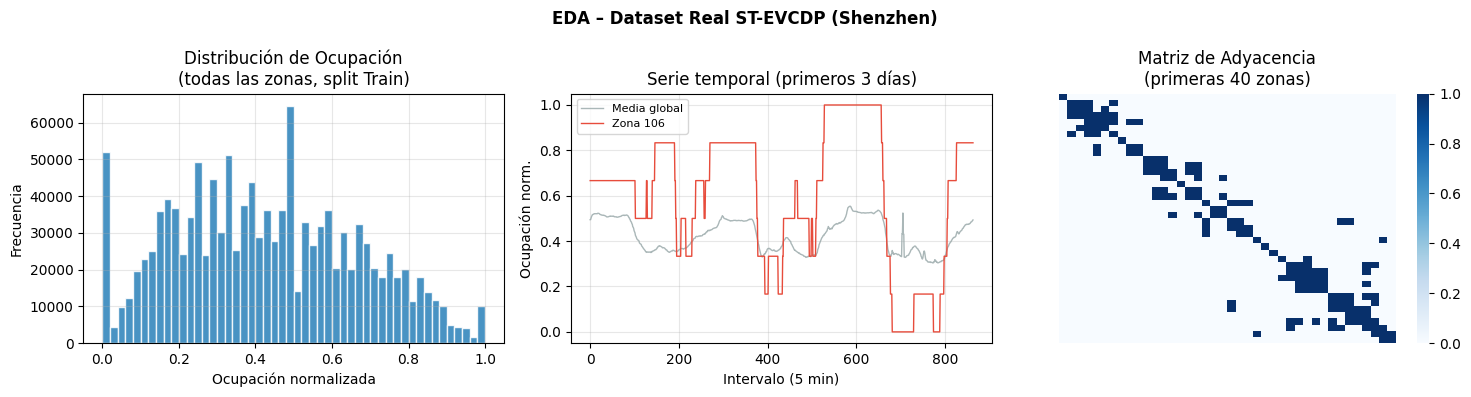

In [6]:
# Normalización Min-Max por zona

def normalize_per_zone(arr: np.ndarray, fit_mask: np.ndarray) -> tuple:
  """
  Escala cada zona independientemente usando solo datos
  de training para evitar data leakage.
  Devuelve (arr_norm, scalers_list)
  """

  arr_norm = arr.copy()
  scalers = []
  for z in range(arr.shape[0]):
    sc = MinMaxScaler(feature_range=(0, 1))
    sc.fit(arr[z, fit_mask].reshape(-1, 1))
    arr_norm[z] = sc.transform(arr[z].reshape(-1, 1)).flatten()
    scalers.append(sc)
  return arr_norm, scalers

# Graph Message Passing con matriz de adyacencia real

def graph_message_passing( occupancy: np.ndarray, adj: np.ndarray, ) -> np.ndarray:
  """
  Agrega la ocupación media de los vecinos reales según adj.csv.
  Implementa la ecuación de Simple Graph Convolution (Wu et al., 2019)
  citada en §3.1.1: h_i = mean_{j ∈ N(i)} x_j.
  Usa la adyacencia binaria del dataset en lugar de distancia euclidiana.
  """

  n_zones = adj.shape[0]
  neighbor_occ = np.zeros_like(occupancy)
  for z in range(n_zones):
    neighbors = np.where(adj[z] == 1)[0]
    if len(neighbors) == 0:
      # Si zona aislada, usar su propia ocupación como fallback
      neighbor_occ[z] = occupancy[z]
    else:
      neighbor_occ[z] = occupancy[neighbors].mean(axis=0)
  return neighbor_occ


# División cronológica 60/20/20 + zonas unseen
def split_dataset(data: dict, unseen_ratio: float = 0.2) -> dict:
  """
  División temporal estricta §4.1.1:
  Train 60% → Day 1–18
  Val 20% → Day 19–24
  Test 20% → Day 25–30
  Zonas unseen (Zero-shot): excluidas del fine-tuning (no del test).
  """

  n_t = data["n_timesteps"]
  t_train_end = int(0.60 * n_t)
  t_val_end = int(0.80 * n_t)
  time_splits = {
      "train": (0, t_train_end),
      "val": (t_train_end, t_val_end),
      "test": (t_val_end, n_t),
  }

  # Normalizar usando solo ventana de entrenamiento
  train_mask = np.zeros(n_t, dtype=bool)
  train_mask[:t_train_end] = True

  occ_norm, occ_scalers = normalize_per_zone(data["occupancy"], train_mask)
  # Precio: normalizar a [0,1] para que sea comparable en el prompt
  price_norm, _ = normalize_per_zone(data["price"], train_mask)

  # Vecinos con adj real
  neighbor_occ = graph_message_passing(occ_norm, data["adj"])

  # Separar zonas seen/unseen aleatoriamente
  all_zones = list(range(data["n_zones"]))
  random.shuffle(all_zones)
  n_unseen = max(1, int(unseen_ratio * data["n_zones"]))
  unseen_zones = all_zones[:n_unseen]
  seen_zones = all_zones[n_unseen:]

  return {
      **data,
      "occ_norm": occ_norm,
      "occ_scalers": occ_scalers,
      "price_norm": price_norm,
      "neighbor_occ": neighbor_occ,
      "seen_zones": seen_zones,
      "unseen_zones": unseen_zones,
      "time_splits": time_splits,
  }

# Ejecutar Sección 1
raw_data = load_stevcdp(dfs)

dataset = split_dataset(raw_data, unseen_ratio=0.2)
print(f"\n → Zonas totales: {dataset['n_zones']}")
print(f" → Zonas vistas: {len(dataset['seen_zones'])}")
print(f" → Zonas unseen: {len(dataset['unseen_zones'])}")
ts = dataset["time_splits"]
print(f" → Train t[0:{ts['train'][1]}] Val t[{ts['val'][0]}:{ts['val'][1]}] "
      f"Test t[{ts['test'][0]}:{ts['test'][1]}]")


# EDA: distribución de ocupación y grafo de adyacencia
fig0, axes0 = plt.subplots(1, 3, figsize=(15, 4))
fig0.suptitle("EDA – Dataset Real ST-EVCDP (Shenzhen)", fontsize=12, fontweight="bold")
# Histograma de tasas de ocupación (todas las zonas, train split)
ts0, te0 = ts["train"]
occ_flat = dataset["occ_norm"][:, ts0:te0].flatten()
axes0[0].hist(occ_flat, bins=50, color="#2980B9", edgecolor="white", alpha=0.85)
axes0[0].set_xlabel("Ocupación normalizada")
axes0[0].set_ylabel("Frecuencia")
axes0[0].set_title("Distribución de Ocupación\n(todas las zonas, split Train)")
axes0[0].grid(alpha=0.3)

# Serie temporal promedio global vs una zona concreta
mean_occ = dataset["occ_norm"].mean(axis=0)
sample_z = dataset["seen_zones"][0]
axes0[1].plot(mean_occ[:288*3], color="#95A5A6", lw=1, label="Media global", alpha=0.8)
axes0[1].plot(dataset["occ_norm"][sample_z, :288*3],
              color="#E74C3C", lw=1, label=f"Zona {sample_z}")
axes0[1].set_xlabel("Intervalo (5 min)")
axes0[1].set_ylabel("Ocupación norm.")
axes0[1].set_title("Serie temporal (primeros 3 días)")
axes0[1].legend(fontsize=8)
axes0[1].grid(alpha=0.3)

# Mapa de calor de la matriz de adyacencia (primeras 40 zonas)
sub = dataset["adj"][:40, :40]
sns.heatmap(sub, ax=axes0[2], cmap="Blues", cbar=True,
            xticklabels=False, yticklabels=False, linewidths=0)
axes0[2].set_title("Matriz de Adyacencia\n(primeras 40 zonas)")
plt.tight_layout()
plt.savefig("./ChatEV_EDA.png", dpi=130, bbox_inches="tight")
print("[S1] EDA guardado en ChatEV_EDA.png")
plt.show()

In [7]:
raw_data = load_stevcdp(dfs)
dataset = split_dataset(raw_data, unseen_ratio=0.2)


Cargando dataset ST-EVCDP desde dfs...
  adj.csv          → (247, 247)
  distance.csv     → (247, 247)
  information.csv  → (247, 9)
     columnas: ['grid', 'count', 'fast_count', 'slow_count', 'area', 'lon', 'la', 'cbd', 'dynamic_pricing']
  time.csv         → 8640 pasos
  occupancy.csv    → (247, 8640)
  duration.csv     → (247, 8640)
  volume.csv       → (247, 8640)
  price.csv        → (247, 8640)

Dataset: 247 zonas × 8640 timesteps


## 1.5 Integración de Datos Meteorológicos

Carga `weather_shenzhen.csv` generado por `fetch_weather.ipynb` (Open-Meteo, sin API key).  
Añade temperatura, humedad y precipitación al `dataset` dict y actualiza las funciones de prompt para incluir weather features, tal como describe el paper en §3.1.1 (Table 1).  

**Si el CSV no está disponible**, la sección continúa sin weather (fallback silencioso).

In [ ]:
# ── Carga weather_shenzhen.csv ─────────────────────────────────────────────
WEATHER_PATH = "/content/drive/MyDrive/MASTER CD/2cuatri/Modelado computacional/Trabajo final/datasets/weather_shenzhen.csv"
WEATHER_AVAILABLE = False

try:
    df_weather = pd.read_csv(WEATHER_PATH)
    assert len(df_weather) >= dataset["n_timesteps"], "CSV demasiado corto"

    # Recortar a exactamente n_timesteps y normalizar [0, 1] con stats de train
    n_t = dataset["n_timesteps"]
    t_train_end = dataset["time_splits"]["train"][1]

    def _norm_weather(col: np.ndarray) -> np.ndarray:
        mn = col[:t_train_end].min()
        mx = col[:t_train_end].max()
        return np.clip((col - mn) / (mx - mn + 1e-8), 0.0, 1.0)

    temp_raw  = df_weather["temperature"].values[:n_t].astype(np.float32)
    hum_raw   = df_weather["humidity"].values[:n_t].astype(np.float32)
    prec_raw  = df_weather["precipitation"].values[:n_t].astype(np.float32)

    dataset["temperature"]   = temp_raw          # °C originales (para prompts legibles)
    dataset["humidity"]      = hum_raw            # % originales
    dataset["precipitation"] = prec_raw           # mm originales
    dataset["temperature_norm"]  = _norm_weather(temp_raw)
    dataset["humidity_norm"]     = _norm_weather(hum_raw)

    WEATHER_AVAILABLE = True
    print(f"[S1.5] Weather cargado: {len(df_weather)} timesteps")
    print(f"       Temp  : {temp_raw.min():.1f}–{temp_raw.max():.1f} °C  (media {temp_raw.mean():.1f})")
    print(f"       Hum   : {hum_raw.min():.0f}–{hum_raw.max():.0f} %    (media {hum_raw.mean():.0f})")
    print(f"       Precip: {prec_raw.max():.1f} mm max")

except FileNotFoundError:
    print("[S1.5] weather_shenzhen.csv no encontrado — ejecuta fetch_weather.ipynb primero.")
    print("       Continuando sin features meteorológicos.")
except Exception as e:
    print(f"[S1.5] Error cargando weather: {e} — continuando sin weather.")


# ── Versión mejorada de get_area_description con weather ──────────────────
def get_area_description_v2(info_row: pd.Series, zone_id: int, t_step: int = None) -> str:
    """
    Versión extendida que añade temperatura y humedad actuales si están disponibles.
    Replica Table 1 del paper: Weather = [22°C, ...].
    """
    def safe(col, fmt="{}", default="N/A"):
        if col in info_row.index:
            v = info_row[col]
            return fmt.format(v) if pd.notna(v) else default
        return default

    # Campos estáticos de information.csv
    count = safe("count", "{:.0f}")
    fast  = safe("fast_count", "{:.0f}")
    slow  = safe("slow_count", "{:.0f}")
    cbd   = "Central Business District" if str(safe("cbd")) == "1.0" else "Non-CBD"
    pric  = "dynamic pricing" if str(safe("dynamic_pricing")) == "1.0" else "flat-rate pricing"
    lon   = safe("lon", "{:.4f}")
    lat   = safe("la",  "{:.4f}")

    desc = (
        f"Area ID={zone_id}, "
        f"Coordinates=[{lat}N, {lon}E], "
        f"Area Type={cbd}, "
        f"Total Piles={count} ({fast} fast / {slow} slow), "
        f"Pricing Scheme={pric}"
    )

    # Añadir weather si disponible
    if WEATHER_AVAILABLE and t_step is not None:
        t = min(t_step, len(dataset["temperature"]) - 1)
        temp = dataset["temperature"][t]
        hum  = dataset["humidity"][t]
        prec = dataset["precipitation"][t]
        rain = "rainy" if prec > 0.1 else "dry"
        desc += f", Weather=[{temp:.1f}°C, humidity {hum:.0f}%, {rain}]"

    return desc


# ── Versión mejorada de transform_to_prompt con weather series ─────────────
def transform_to_prompt_v2(
    zone_id:      int,
    info_row:     pd.Series,
    local_occ:    np.ndarray,
    neighbor_occ: np.ndarray,
    price_w:      np.ndarray,
    duration_w:   np.ndarray,
    target_val:   float,
    t_step:       int = None,
) -> tuple:
    """
    Prompt extendido con weather features (§3.1.1, Table 1 del paper).
    Si weather no disponible, idéntico a transform_to_prompt original.
    """
    fmt = lambda arr: "[" + ", ".join(f"{v:.2f}" for v in arr) + "]"
    area_desc = get_area_description_v2(info_row, zone_id, t_step)

    # Series de weather en la ventana histórica
    weather_lines = ""
    if WEATHER_AVAILABLE and t_step is not None:
        lw = max(0, t_step - len(local_occ))
        temp_w = dataset["temperature_norm"][lw: t_step]
        hum_w  = dataset["humidity_norm"][lw: t_step]
        if len(temp_w) == len(local_occ):
            weather_lines = (
                f"Temperature (normalized)={fmt(temp_w)}; "
                f"Humidity (normalized)={fmt(hum_w)}. "
            )

    input_text = (
        "You are an expert in electric vehicle charging management, "
        "who is good at <charging demand prediction>. "
        f"We are now in {area_desc}. "
        "Given the following time series of historical charging data, "
        f"Local Charging Occupancy={fmt(local_occ)}; "
        f"Average Neighboring Charging Occupancy={fmt(neighbor_occ)}; "
        f"Charging Price={fmt(price_w)}; "
        f"Charging Duration={fmt(duration_w)}. "
        + weather_lines +
        "Now, pay attention! Your task is to <predict the charging demand "
        "in the area for the next hour> by analyzing the given information "
        "and leveraging your common sense. "
        "In your answer, you should provide the value of your prediction only."
    )
    return input_text, f"{target_val:.2f}"


# Verificar con un ejemplo
if WEATHER_AVAILABLE:
    sample_z = dataset["seen_zones"][0]
    sample_t = dataset["time_splits"]["test"][0] + LOOKBACK_W + 10
    ex_prompt, _ = transform_to_prompt_v2(
        zone_id=sample_z,
        info_row=dataset["info"].iloc[sample_z],
        local_occ=dataset["occ_norm"][sample_z, sample_t-LOOKBACK_W:sample_t],
        neighbor_occ=dataset["neighbor_occ"][sample_z, sample_t-LOOKBACK_W:sample_t],
        price_w=dataset["price_norm"][sample_z, sample_t-LOOKBACK_W:sample_t],
        duration_w=np.zeros(LOOKBACK_W),
        target_val=0.5,
        t_step=sample_t,
    )
    print(f"\n[S1.5] Prompt v2 ejemplo (con weather):")
    print(f"  {ex_prompt[:350]}...")
else:
    print("[S1.5] transform_to_prompt_v2 disponible (sin weather hasta cargar CSV).")


# ── Carga addresses_shenzhen.csv ──────────────────────────────────────────
ADDR_PATH = "/content/drive/MyDrive/MASTER CD/2cuatri/Modelado computacional/Trabajo final/datasets/addresses_shenzhen.csv"
ADDRESS_AVAILABLE = False

try:
    df_addr = pd.read_csv(ADDR_PATH)
    dataset["addresses"] = df_addr.set_index("zone_id")["address_short"].to_dict()
    ADDRESS_AVAILABLE = True
    print(f"[S1.5] Addresses cargadas: {len(df_addr)} zonas")
    print(f"       Ejemplo zona 0: {dataset['addresses'].get(0, 'N/A')}")
except FileNotFoundError:
    print("[S1.5] addresses_shenzhen.csv no encontrado — ejecuta fetch_address.ipynb primero.")
except Exception as e:
    print(f"[S1.5] Error cargando addresses: {e}")


# ── Carga spatial_features_shenzhen.csv ───────────────────────────────────
SPATIAL_PATH = "/content/drive/MyDrive/MASTER CD/2cuatri/Modelado computacional/Trabajo final/datasets/spatial_features_shenzhen.csv"
SPATIAL_AVAILABLE = False

try:
    df_spatial = pd.read_csv(SPATIAL_PATH)
    dataset["road_length"]  = df_spatial.set_index("zone_id")["road_length_km"].to_dict()
    dataset["poi_count"]    = df_spatial.set_index("zone_id")["poi_count"].to_dict()
    dataset["road_length_norm"] = df_spatial.set_index("zone_id")["road_length_km_norm"].to_dict()
    dataset["poi_count_norm"]   = df_spatial.set_index("zone_id")["poi_count_norm"].to_dict()
    SPATIAL_AVAILABLE = True
    print(f"[S1.5] Spatial features cargadas: {len(df_spatial)} zonas")
    z0 = df_spatial.iloc[0]
    print(f"       Zona {int(z0['zone_id'])}: road={z0['road_length_km']:.2f} km, poi={z0['poi_count']:.0f}")
except FileNotFoundError:
    print("[S1.5] spatial_features_shenzhen.csv no encontrado — ejecuta fetch_spatial_features.ipynb primero.")
except Exception as e:
    print(f"[S1.5] Error cargando spatial features: {e}")




# ── Carga calendar_features.csv ───────────────────────────────────────────
CALENDAR_PATH = "/content/drive/MyDrive/MASTER CD/2cuatri/Modelado computacional/Trabajo final/datasets/calendar_features.csv"
CALENDAR_AVAILABLE = False

try:
    df_cal = pd.read_csv(CALENDAR_PATH)
    assert len(df_cal) >= dataset["n_timesteps"], "CSV demasiado corto"

    dataset["cal_is_weekend"]   = df_cal["is_weekend"].values[:dataset["n_timesteps"]]
    dataset["cal_is_holiday"]   = df_cal["is_holiday"].values[:dataset["n_timesteps"]]
    dataset["cal_holiday_name"] = df_cal["holiday_name"].fillna("").values[:dataset["n_timesteps"]]
    dataset["cal_is_peak"]      = df_cal["is_peak_hour"].values[:dataset["n_timesteps"]]
    dataset["cal_time_period"]  = df_cal["time_period"].values[:dataset["n_timesteps"]]
    dataset["cal_day_name"]     = df_cal["day_name"].values[:dataset["n_timesteps"]]
    dataset["cal_hour_sin"]     = df_cal["hour_sin"].values[:dataset["n_timesteps"]].astype(np.float32)
    dataset["cal_hour_cos"]     = df_cal["hour_cos"].values[:dataset["n_timesteps"]].astype(np.float32)

    CALENDAR_AVAILABLE = True
    n_weekends  = dataset["cal_is_weekend"].sum()
    n_holidays  = dataset["cal_is_holiday"].sum()
    n_peak      = dataset["cal_is_peak"].sum()
    print(f"[S1.5] Calendar cargado: {len(df_cal)} timesteps")
    print(f"       Fin de semana: {n_weekends} steps | Festivos: {n_holidays} steps | Hora punta: {n_peak} steps")

except FileNotFoundError:
    print("[S1.5] calendar_features.csv no encontrado — ejecuta fetch_calendar.ipynb primero.")
except Exception as e:
    print(f"[S1.5] Error cargando calendar: {e}")


# ── Versión final get_area_description_v2 (con address + road + POI + weather) ──
def get_area_description_v2(info_row: pd.Series, zone_id: int, t_step: int = None) -> str:
    """
    Area characterization completa replicando Table 1 del paper:
    Coordinates, Address, Charging Pile Number, Road Length, Weather.
    Usa los datos de Nominatim, Overpass y Open-Meteo si están disponibles.
    """
    def safe(col, fmt="{}", default="N/A"):
        if col in info_row.index:
            v = info_row[col]
            return fmt.format(v) if pd.notna(v) else default
        return default

    count = safe("count", "{:.0f}")
    fast  = safe("fast_count", "{:.0f}")
    slow  = safe("slow_count", "{:.0f}")
    cbd   = "Central Business District" if str(safe("cbd")) == "1.0" else "Non-CBD"
    pric  = "dynamic pricing" if str(safe("dynamic_pricing")) == "1.0" else "flat-rate pricing"
    lon   = safe("lon", "{:.4f}")
    lat   = safe("la",  "{:.4f}")

    parts = [
        f"Area ID={zone_id}",
        f"Coordinates=[{lat}N, {lon}E]",
    ]

    if ADDRESS_AVAILABLE:
        addr = dataset["addresses"].get(zone_id, dataset["addresses"].get(str(zone_id), "N/A"))
        parts.append(f"Address={addr}")

    parts += [
        f"Area Type={cbd}",
        f"Total Piles={count} ({fast} fast / {slow} slow)",
        f"Pricing={pric}",
    ]

    if SPATIAL_AVAILABLE:
        road = dataset["road_length"].get(zone_id, dataset["road_length"].get(str(zone_id), None))
        poi  = dataset["poi_count"].get(zone_id, dataset["poi_count"].get(str(zone_id), None))
        if road is not None:
            parts.append(f"Road Length={road:.2f} km")
        if poi is not None:
            parts.append(f"POI Count={int(poi)}")

    if WEATHER_AVAILABLE and t_step is not None:
        t = min(t_step, len(dataset["temperature"]) - 1)
        temp = dataset["temperature"][t]
        hum  = dataset["humidity"][t]
        prec = dataset["precipitation"][t]
        rain = "rainy" if prec > 0.1 else "dry"
        parts.append(f"Weather=[{temp:.1f}°C, humidity {hum:.0f}%, {rain}]")

    if CALENDAR_AVAILABLE and t_step is not None:
        t = min(t_step, len(dataset["cal_day_name"]) - 1)
        day_name   = dataset["cal_day_name"][t]
        period     = dataset["cal_time_period"][t]
        is_wknd    = bool(dataset["cal_is_weekend"][t])
        is_hol     = bool(dataset["cal_is_holiday"][t])
        is_peak    = bool(dataset["cal_is_peak"][t])
        hol_name   = dataset["cal_holiday_name"][t]
        day_type   = "Holiday" if is_hol else ("Weekend" if is_wknd else "Weekday")
        peak_str   = "peak electricity hour" if is_peak else "off-peak hour"
        cal_str    = f"{day_name} {period}, {day_type}, {peak_str}"
        if is_hol and hol_name:
            cal_str += f" ({hol_name})"
        parts.append(f"Time Context=[{cal_str}]")

    return ", ".join(parts)


print(f"\n[S1.5] Features disponibles: weather={WEATHER_AVAILABLE}, address={ADDRESS_AVAILABLE}, spatial={SPATIAL_AVAILABLE}, calendar={CALENDAR_AVAILABLE}")


## 2. Reformulación Text-to-Text con Datos Reales

In [8]:
# Construcción del prompt con columnas reales de information.csv
def get_area_description(info_row: pd.Series, zone_id: int) -> str:
    """
    Genera la caracterización de área a partir de information.csv.
    Columnas esperadas: pile_capacity, longitude, latitude, is_cbd,
    is_time_pricing (§4.1.1 del paper y README del dataset).
    Mapea campos desconocidos con un fallback seguro.
    """
    def safe(col, fmt="{}", default="N/A"):
        if col in info_row.index:
            v = info_row[col]
            return fmt.format(v) if pd.notna(v) else default
        return default

    lat  = safe("latitude",  "{:.4f}")
    lon  = safe("longitude", "{:.4f}")
    pile = safe("pile_capacity", "{:.0f}")
    cbd  = "Central Business District" if safe("is_cbd") == "1.0" else "Non-CBD"
    pric = "time-based pricing"        if safe("is_time_pricing") == "1.0" \
           else "flat-rate pricing"

    return (
        f"Area ID={zone_id}, "
        f"Coordinates=[{lat}N, {lon}E], "
        f"Area Type={cbd}, "
        f"Pile Capacity={pile} piles, "
        f"Pricing Scheme={pric}"
    )


def transform_to_prompt(
    zone_id:      int,
    info_row:     pd.Series,
    local_occ:    np.ndarray,   # (lookback_w,) – ocupación local norm.
    neighbor_occ: np.ndarray,   # (lookback_w,) – vecinos (graph MP)
    price_w:      np.ndarray,   # (lookback_w,) – precio norm.
    duration_w:   np.ndarray,   # (lookback_w,) – duración norm.
    target_val:   float,
) -> tuple:
    """
    Convierte arrays numéricos en el formato text-to-text del paper (§3.1.1).
    Incluye: role-playing · area characterization · series · task instruction.
    Usa los 5 campos reales de information.csv y 4 series temporales del dataset.
    """
    fmt = lambda arr: "[" + ", ".join(f"{v:.2f}" for v in arr) + "]"
    area_desc = get_area_description(info_row, zone_id)

    input_text = (
        "You are an expert in electric vehicle charging management, "
        "who is good at <charging demand prediction>. "
        f"We are now in {area_desc}. "
        "Given the following time series of historical charging data, "
        f"Local Charging Occupancy={fmt(local_occ)}; "
        f"Average Neighboring Charging Occupancy={fmt(neighbor_occ)}; "
        f"Charging Price={fmt(price_w)}; "
        f"Charging Duration={fmt(duration_w)}. "
        "Now, pay attention! Your task is to <predict the charging demand "
        "in the area for the next hour> by analyzing the given information "
        "and leveraging your common sense. "
        "In your answer, you should provide the value of your prediction only."
    )
    target_text = f"{target_val:.2f}"
    return input_text, target_text


# Dataset PyTorch con datos reales
class STEVCDPDataset(Dataset):
    """
    Construye pares tokenizados (input_ids, labels) a partir de los arrays
    del dataset real. Ventana deslizante temporal de LOOKBACK_W pasos.
    La normalización ya fue aplicada en split_dataset; aquí solo indexamos.
    """
    def __init__(
        self,
        zone_ids:   list,
        data:       dict,
        tokenizer,
        split:      str  = "train",
        lookback_w: int  = 12,   # 1 hora de historia (§4.1.3)
        horizon:    int  = 6,    # predecir 30 min (§4.1.3)
        max_length: int  = 256,
        stride:     int  = 6,    # paso de ventana: reduce tamaño dataset en CPU
    ):
        self.tokenizer  = tokenizer
        self.max_length = max_length
        self.samples    = []

        ts, te     = data["time_splits"][split]
        info       = data["info"]
        occ        = data["occ_norm"]
        n_occ      = data["neighbor_occ"]
        price      = data["price_norm"]
        # Normalizar duration también (no normalizada aún en split_dataset)
        dur_raw    = data["duration"]
        dur_max    = dur_raw[:, :data["time_splits"]["train"][1]].max()
        dur_norm   = np.clip(dur_raw / (dur_max + 1e-8), 0, 1)

        for z in zone_ids:
            # Mapear zone_id al índice de fila en information.csv
            if z < len(info):
                row = info.iloc[z]
            else:
                row = info.iloc[0]   # fallback si hay discrepancia de índices

            for t in range(ts + lookback_w, te - horizon, stride):
                local_w  = occ[z,  t - lookback_w: t]
                neigh_w  = n_occ[z, t - lookback_w: t]
                price_w  = price[z, t - lookback_w: t]
                dur_w    = dur_norm[z, t - lookback_w: t]
                tgt      = float(np.mean(occ[z, t: t + horizon]))

                inp, tgt_str = transform_to_prompt(
                    zone_id=z, info_row=row,
                    local_occ=local_w, neighbor_occ=neigh_w,
                    price_w=price_w, duration_w=dur_w,
                    target_val=tgt,
                )
                self.samples.append((inp, tgt_str))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        inp_txt, tgt_txt = self.samples[idx]
        enc = self.tokenizer(
            inp_txt, max_length=self.max_length,
            truncation=True, padding="max_length",
            return_tensors="pt"
        )
        dec = self.tokenizer(
            tgt_txt, max_length=8,
            truncation=True, padding="max_length",
            return_tensors="pt"
        )
        labels = dec["input_ids"].squeeze()
        labels[labels == self.tokenizer.pad_token_id] = -100
        return {
            "input_ids":      enc["input_ids"].squeeze(),
            "attention_mask": enc["attention_mask"].squeeze(),
            "labels":         labels,
            "target_val":     torch.tensor(float(tgt_txt), dtype=torch.float32),
        }


# Inicializar tokenizador y datasets
print("\n[S2] Cargando tokenizador T5 y construyendo datasets...")
tokenizer = T5Tokenizer.from_pretrained(MODEL_NAME, legacy=False)

LOOKBACK_W = 12   # 1 hora de historia
HORIZON    = 6    # 30 min de predicción
STRIDE     = 12   # paso de ventana (1 hora) → equilibrio velocidad/cobertura

train_ds = STEVCDPDataset(
    dataset["seen_zones"], dataset, tokenizer,
    split="train", lookback_w=LOOKBACK_W, horizon=HORIZON, stride=STRIDE
)
val_ds = STEVCDPDataset(
    dataset["seen_zones"], dataset, tokenizer,
    split="val", lookback_w=LOOKBACK_W, horizon=HORIZON, stride=STRIDE
)
test_ds_seen = STEVCDPDataset(
    dataset["seen_zones"], dataset, tokenizer,
    split="test", lookback_w=LOOKBACK_W, horizon=HORIZON, stride=STRIDE
)
test_ds_zero = STEVCDPDataset(
    dataset["unseen_zones"], dataset, tokenizer,
    split="test", lookback_w=LOOKBACK_W, horizon=HORIZON, stride=STRIDE
)

print(f"  → Train:      {len(train_ds):>6} muestras")
print(f"  → Val:        {len(val_ds):>6} muestras")
print(f"  → Test seen:  {len(test_ds_seen):>6} muestras")
print(f"  → Test zero:  {len(test_ds_zero):>6} muestras (zero-shot)")

# Imprimir un ejemplo del prompt para verificar el formato
ex_inp, ex_tgt = train_ds.samples[0]
print(f"\n[S2] Ejemplo de prompt (truncado a 300 chars):")
print(f"  INPUT:  {ex_inp[:300]}...")
print(f"  TARGET: {ex_tgt}")




[S2] Cargando tokenizador T5 y construyendo datasets...


tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

  → Train:       85338 muestras
  → Val:         28314 muestras
  → Test seen:   28314 muestras
  → Test zero:    7007 muestras (zero-shot)

[S2] Ejemplo de prompt (truncado a 300 chars):
  INPUT:  You are an expert in electric vehicle charging management, who is good at <charging demand prediction>. We are now in Area ID=218, Coordinates=[N/AN, N/AE], Area Type=Non-CBD, Pile Capacity=N/A piles, Pricing Scheme=flat-rate pricing. Given the following time series of historical charging data, Loca...
  TARGET: 0.75


## 3. Meta-Aprendizaje Reptile sobre Dataset Real


In [9]:
print(f"\n[S3] Cargando modelo {MODEL_NAME}...")
model = T5ForConditionalGeneration.from_pretrained(MODEL_NAME).to(DEVICE)
print(f"  → Parámetros: {sum(p.numel() for p in model.parameters()):,}")


def reptile_step(
    meta_model:  T5ForConditionalGeneration,
    zone_ids:    list,
    data:        dict,
    tokenizer,
    s_steps:     int   = 3,
    inner_lr:    float = 1e-4,
    epsilon:     float = 0.1,
    lookback_w:  int   = 12,
    horizon:     int   = 6,
    stride:      int   = 12,
) -> float:
    """
    Un paso del Algoritmo Reptile (Nichol & Schulman, 2018) sobre datos reales.
    Support set: primeros 60% del split train de la zona muestreada.
    Query set:   últimos 40% del split train.
    Actualización: θ ← θ + ε·(θ̂ − θ)  (interpolación en espacio de pesos).
    """
    task_model = copy.deepcopy(meta_model).to(DEVICE)
    inner_opt  = torch.optim.Adam(task_model.parameters(), lr=inner_lr)

    zone      = random.choice(zone_ids)
    ts, te    = data["time_splits"]["train"]
    mid_t     = ts + int(0.6 * (te - ts))

    # Construir Support y Query sin modificar el dict original (deep copy de splits)
    sup_data = {**data, "time_splits": {**data["time_splits"], "train": (ts, mid_t)}}
    qry_data = {**data, "time_splits": {**data["time_splits"], "train": (mid_t, te)}}

    def make_loader(d, split="train"):
        ds = STEVCDPDataset(
            [zone], d, tokenizer, split=split,
            lookback_w=lookback_w, horizon=horizon, stride=stride
        )
        if len(ds) == 0:
            return None
        return DataLoader(ds, batch_size=4, shuffle=True)

    sup_loader = make_loader(sup_data)
    qry_loader = make_loader(qry_data)
    if sup_loader is None or qry_loader is None:
        return 0.0

    # S pasos SGD sobre Support Set
    task_model.train()
    for _ in range(s_steps):
        b = next(iter(sup_loader))
        inner_opt.zero_grad()
        loss = task_model(
            input_ids=b["input_ids"].to(DEVICE),
            attention_mask=b["attention_mask"].to(DEVICE),
            labels=b["labels"].to(DEVICE),
        ).loss
        loss.backward()
        inner_opt.step()

    # 1 paso SGD sobre Query Set
    task_model.train()
    qb = next(iter(qry_loader))
    inner_opt.zero_grad()
    q_out = task_model(
        input_ids=qb["input_ids"].to(DEVICE),
        attention_mask=qb["attention_mask"].to(DEVICE),
        labels=qb["labels"].to(DEVICE),
    )
    q_out.loss.backward()
    inner_opt.step()
    query_loss = q_out.loss.item()

    # Interpolación Reptile: θ ← θ + ε·(θ̂ − θ)
    with torch.no_grad():
        for mp, tp in zip(meta_model.parameters(), task_model.parameters()):
            mp.data.add_(epsilon * (tp.data - mp.data))

    return query_loss


def train_chatev(
    model,
    dataset,
    tokenizer,
    n_epochs:  int   = 40,
    s_steps:   int   = 3,
    inner_lr:  float = 1e-4,
    epsilon:   float = 0.1,
    patience:  int   = 7,
    lookback_w: int  = 12,
    horizon:   int   = 6,
    stride:    int   = 12,
) -> list:
    """
    Bucle de meta-entrenamiento externo. Registra la NLL del Query Set
    y aplica early stopping si no mejora en `patience` epochs consecutivos.
    """
    seen   = dataset["seen_zones"]
    losses = []
    best   = float("inf")
    no_imp = 0

    for epoch in range(1, n_epochs + 1):
        loss = reptile_step(
            meta_model=model, zone_ids=seen, data=dataset,
            tokenizer=tokenizer, s_steps=s_steps, inner_lr=inner_lr,
            epsilon=epsilon, lookback_w=lookback_w, horizon=horizon, stride=stride,
        )
        losses.append(loss)

        if loss < best - 1e-5:
            best   = loss
            no_imp = 0
        else:
            no_imp += 1

        if epoch % 5 == 0 or epoch == 1:
            print(f"  Epoch {epoch:>3}/{n_epochs}  NLL: {loss:.5f}  best: {best:.5f}")

        if no_imp >= patience:
            print(f"  [Early Stopping] sin mejora en {patience} epochs → epoch {epoch}")
            break

    return losses


print("\n[S3] Meta-entrenamiento Reptile (datos reales ST-EVCDP)...")
train_losses = train_chatev(
    model, dataset, tokenizer,
    n_epochs=40, s_steps=3, inner_lr=1e-4, epsilon=0.1, patience=7,
    lookback_w=LOOKBACK_W, horizon=HORIZON, stride=STRIDE,
)
print(f"  → Completado. Epochs ejecutados: {len(train_losses)}")




[S3] Cargando modelo t5-small...


config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

  → Parámetros: 60,506,624

[S3] Meta-entrenamiento Reptile (datos reales ST-EVCDP)...
  Epoch   1/40  NLL: 4.16950  best: 4.16950
  Epoch   5/40  NLL: 1.98295  best: 1.98295
  Epoch  10/40  NLL: 1.11728  best: 1.11728
  Epoch  15/40  NLL: 0.70100  best: 0.70100
  Epoch  20/40  NLL: 0.48874  best: 0.48874
  Epoch  25/40  NLL: 0.98143  best: 0.39132
  [Early Stopping] sin mejora en 7 epochs → epoch 29
  → Completado. Epochs ejecutados: 29


## 4. Inferencia, Evaluación y Visualizaciones



[S4] Evaluación Zero-Shot sobre zonas no vistas en entrenamiento...
[S4] Evaluación Full-Shot sobre zonas vistas...

  ┌────────────────────────────────────────────────────────────┐
  │           Resultados Evaluación – Dataset Real ST-EVCDP    │
  ├───────────────────┬──────────────┬───────────────┬─────────┤
  │ Modelo            │  Escenario   │ MAE (×10⁻²)  │RMSE(×10⁻²)│
  ├───────────────────┼──────────────┼───────────────┼─────────┤

  ┌───────────────────┬────────────┬─────────────┬────────────┐
  │ Modelo            │ Escenario  │ MAE (×10⁻²)│RMSE(×10⁻²)│
  ├───────────────────┼────────────┼─────────────┼────────────┤
  │ ChatEV (T5-small) │ Full-shot  │      6.9267 │    13.4353 │
  │ Baseline hist.    │ Full-shot  │      4.4697 │     8.2972 │
  │ ChatEV (T5-small) │ Zero-shot  │      7.2500 │    14.6095 │
  │ Baseline hist.    │ Zero-shot  │      3.5603 │     8.2063 │
  │ ChatEV* paper     │ Full-shot  │      3.2900 │     5.4000 │
  │ ChatEV* paper     │ Zero-shot  │      3.6

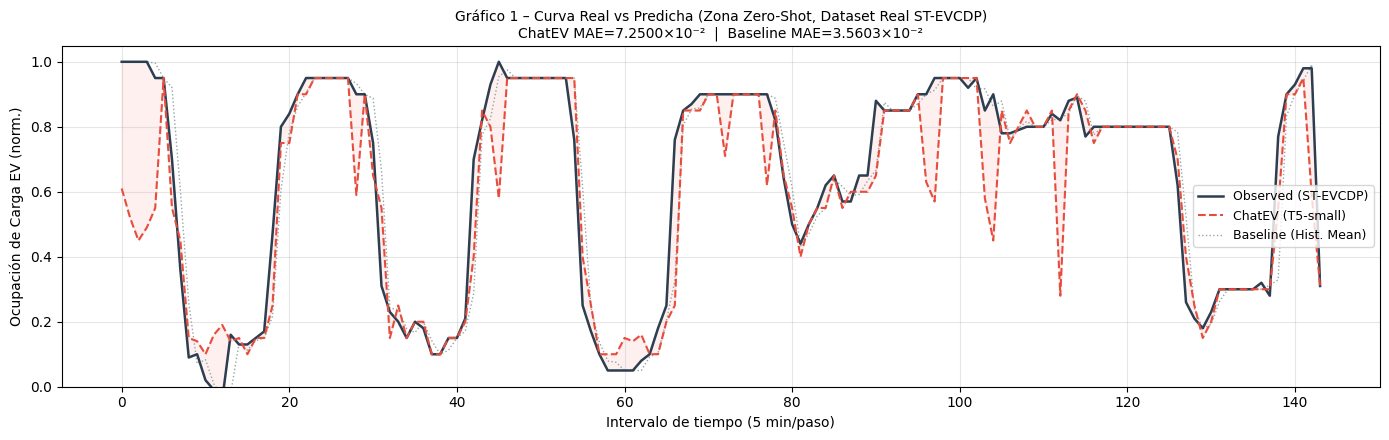

[S4] Gráfico 2 guardado en ChatEV_BarMAE.png


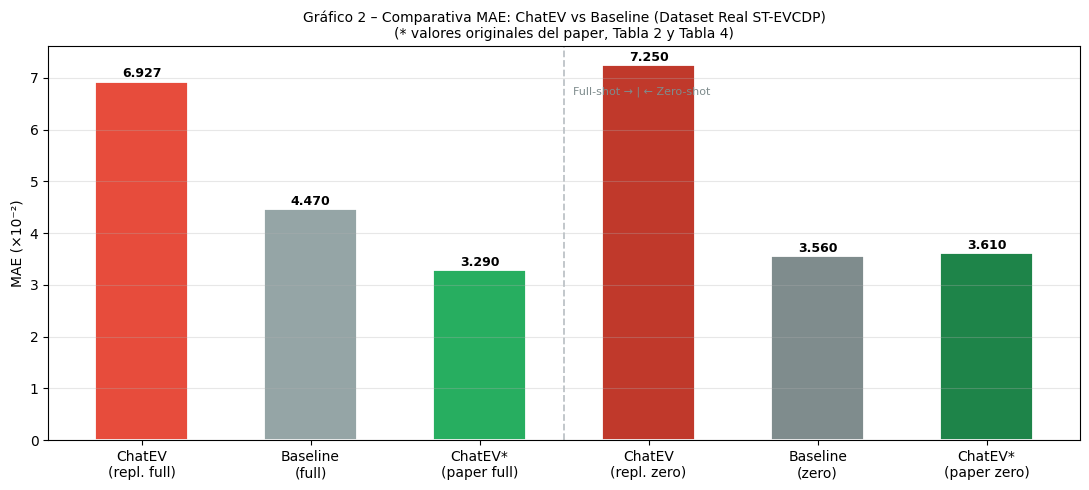

[S4] Gráfico 3 guardado en ChatEV_Loss.png


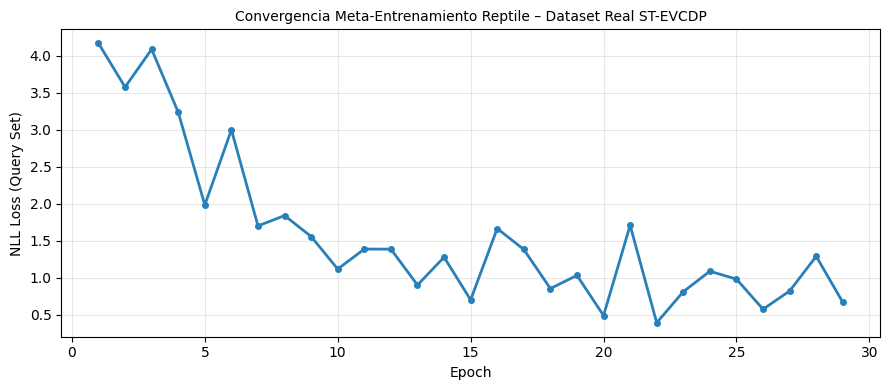

In [10]:
def predict_numeric(model, tokenizer, input_texts: list, max_new: int = 8) -> np.ndarray:
    """
    Greedy Decoding (§3.1.2). Convierte el string generado a float[0,1].
    Fallback a la media global si el modelo genera texto no numérico.
    """
    model.eval()
    preds = []
    with torch.no_grad():
        for txt in input_texts:
            enc = tokenizer(
                txt, max_length=256, truncation=True, return_tensors="pt"
            ).to(DEVICE)
            out = model.generate(
                input_ids=enc["input_ids"],
                attention_mask=enc["attention_mask"],
                max_new_tokens=max_new, num_beams=1, do_sample=False,
            )
            decoded = tokenizer.decode(out[0], skip_special_tokens=True).strip()
            try:
                preds.append(float(np.clip(float(decoded), 0.0, 1.0)))
            except ValueError:
                preds.append(0.5)
    return np.array(preds)


def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    return {
        "MAE":  mean_absolute_error(y_true, y_pred),
        "RMSE": math.sqrt(mean_squared_error(y_true, y_pred)),
    }


def baseline_historical_mean(samples: list) -> np.ndarray:
    """
    Baseline naive: predice la media de la serie local del prompt.
    Extrae los valores del texto ya formateado para coherencia absoluta.
    """
    preds = []
    for inp, _ in samples:
        try:
            s = inp.index("Local Charging Occupancy=[") + len("Local Charging Occupancy=[")
            e = inp.index("]", s)
            vals = [float(v.strip()) for v in inp[s:e].split(",")]
            preds.append(float(np.mean(vals)))
        except Exception:
            preds.append(0.5)
    return np.array(preds)


# Evaluación Zero-shot (zonas unseen)
print("\n[S4] Evaluación Zero-Shot sobre zonas no vistas en entrenamiento...")
MAX_EVAL = min(300, len(test_ds_zero))
zero_samples  = test_ds_zero.samples[:MAX_EVAL]
inp_zero      = [s[0] for s in zero_samples]
true_zero     = np.array([float(s[1]) for s in zero_samples])
pred_zero     = predict_numeric(model, tokenizer, inp_zero)
base_zero     = baseline_historical_mean(zero_samples)

m_chatev_zero = compute_metrics(true_zero, pred_zero)
m_base_zero   = compute_metrics(true_zero, base_zero)

# Evaluación Full-shot (zonas vistas)
print("[S4] Evaluación Full-Shot sobre zonas vistas...")
MAX_FULL = min(300, len(test_ds_seen))
full_samples  = test_ds_seen.samples[:MAX_FULL]
inp_full      = [s[0] for s in full_samples]
true_full     = np.array([float(s[1]) for s in full_samples])
pred_full     = predict_numeric(model, tokenizer, inp_full)
base_full     = baseline_historical_mean(full_samples)

m_chatev_full = compute_metrics(true_full, pred_full)
m_base_full   = compute_metrics(true_full, base_full)

# Imprimir tabla de resultados
print("\n  ┌────────────────────────────────────────────────────────────┐")
print("  │           Resultados Evaluación – Dataset Real ST-EVCDP    │")
print("  ├───────────────────┬──────────────┬───────────────┬─────────┤")
print("  │ Modelo            │  Escenario   │ MAE (×10⁻²)  │RMSE(×10⁻²)│")
print("  ├───────────────────┼──────────────┼───────────────┼─────────┤")
# Tabla de resultados
rows = [
    ("ChatEV (T5-small)", "Full-shot",  m_chatev_full["MAE"]*100, m_chatev_full["RMSE"]*100),
    ("Baseline hist.",    "Full-shot",  m_base_full["MAE"]*100,   m_base_full["RMSE"]*100),
    ("ChatEV (T5-small)", "Zero-shot",  m_chatev_zero["MAE"]*100, m_chatev_zero["RMSE"]*100),
    ("Baseline hist.",    "Zero-shot",  m_base_zero["MAE"]*100,   m_base_zero["RMSE"]*100),
    ("ChatEV* paper",     "Full-shot",  3.29,                      5.40),
    ("ChatEV* paper",     "Zero-shot",  3.61,                      5.91),
]
print("\n  ┌───────────────────┬────────────┬─────────────┬────────────┐")
print(  "  │ Modelo            │ Escenario  │ MAE (×10⁻²)│RMSE(×10⁻²)│")
print(  "  ├───────────────────┼────────────┼─────────────┼────────────┤")
for mdl, esc, mae, rmse in rows:
    print(f"  │ {mdl:<17} │ {esc:<10} │ {mae:>11.4f} │ {rmse:>10.4f} │")
print(  "  └───────────────────┴────────────┴─────────────┴────────────┘")
print("  * Resultados originales del paper con Sentence-T5 y datos reales completos.")


# Gráfico 1: Curva demanda real vs predicha (zona zero-shot)
fig1, ax1 = plt.subplots(figsize=(14, 4.5))

N_VIZ = min(144, MAX_EVAL)   # 12 horas de datos (144 × 5min)
x     = np.arange(N_VIZ)

# Intentar usar timestamps reales del dataset
try:
    ts_start = dataset["time_splits"]["test"][0]
    t_labels = dataset["timestamps"][ts_start: ts_start + N_VIZ]
    use_dates = True
except Exception:
    t_labels  = x
    use_dates = False

ax1.plot(x, true_zero[:N_VIZ],  color="#2C3E50", lw=1.8, label="Observed (ST-EVCDP)", zorder=3)
ax1.plot(x, pred_zero[:N_VIZ],  color="#E74C3C", lw=1.5, ls="--", label="ChatEV (T5-small)", zorder=4)
ax1.plot(x, base_zero[:N_VIZ],  color="#95A5A6", lw=1.0, ls=":",  label="Baseline (Hist. Mean)", zorder=2)
ax1.fill_between(x, true_zero[:N_VIZ], pred_zero[:N_VIZ], alpha=0.08, color="#E74C3C")

ax1.set_xlabel("Intervalo de tiempo (5 min/paso)", fontsize=10)
ax1.set_ylabel("Ocupación de Carga EV (norm.)", fontsize=10)
ax1.set_title(
    "Gráfico 1 – Curva Real vs Predicha (Zona Zero-Shot, Dataset Real ST-EVCDP)\n"
    f"ChatEV MAE={m_chatev_zero['MAE']*100:.4f}×10⁻²  |  "
    f"Baseline MAE={m_base_zero['MAE']*100:.4f}×10⁻²",
    fontsize=10
)
ax1.legend(fontsize=9)
ax1.set_ylim(0.0, 1.05)
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("./ChatEV_Pred_Zero.png", dpi=150, bbox_inches="tight")
print("[S4] Gráfico 1 guardado en ChatEV_Pred_Zero.png")
plt.show()

# Gráfico 2: Barras comparativas MAE por escenario
fig2, ax2 = plt.subplots(figsize=(11, 5))

labels_g = [
    "ChatEV\n(repl. full)", "Baseline\n(full)", "ChatEV*\n(paper full)",
    "ChatEV\n(repl. zero)", "Baseline\n(zero)", "ChatEV*\n(paper zero)",
]
values_g = [
    m_chatev_full["MAE"]*100, m_base_full["MAE"]*100, 3.29,
    m_chatev_zero["MAE"]*100, m_base_zero["MAE"]*100, 3.61,
]
colors_g = [
    "#E74C3C", "#95A5A6", "#27AE60",
    "#C0392B", "#7F8C8D", "#1E8449",
]
bars = ax2.bar(labels_g, values_g, color=colors_g, width=0.55,
               edgecolor="white", linewidth=1.3)
for b, v in zip(bars, values_g):
    ax2.text(b.get_x() + b.get_width()/2, b.get_height() + 0.02,
             f"{v:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax2.axvline(2.5, color="#BDC3C7", lw=1.3, ls="--")
ax2.text(2.55, max(values_g)*0.92, "Full-shot → | ← Zero-shot",
         fontsize=8, color="#7F8C8D")
ax2.set_ylabel("MAE (×10⁻²)", fontsize=10)
ax2.set_title(
    "Gráfico 2 – Comparativa MAE: ChatEV vs Baseline (Dataset Real ST-EVCDP)\n"
    "(* valores originales del paper, Tabla 2 y Tabla 4)",
    fontsize=10
)
ax2.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("./ChatEV_BarMAE.png", dpi=150, bbox_inches="tight")
print("[S4] Gráfico 2 guardado en ChatEV_BarMAE.png")
plt.show()

# Gráfico 3: Curva de convergencia Reptile
fig3, ax3 = plt.subplots(figsize=(9, 4))
ax3.plot(range(1, len(train_losses)+1), train_losses,
         color="#2980B9", lw=2, marker="o", ms=4)
ax3.set_xlabel("Epoch", fontsize=10)
ax3.set_ylabel("NLL Loss (Query Set)", fontsize=10)
ax3.set_title("Convergencia Meta-Entrenamiento Reptile – Dataset Real ST-EVCDP", fontsize=10)
ax3.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("./ChatEV_Loss.png", dpi=150, bbox_inches="tight")
print("[S4] Gráfico 3 guardado en ChatEV_Loss.png")
plt.show()



## 4.5 Few-Shot Forecasting con Datos Limitados

Replica **§4.2.2 y Tabla 3** del paper: evalúa ChatEV cuando solo se dispone del **5%, 10%, 15% y 20%** de los timesteps de entrenamiento.  
Procedimiento: partir del modelo meta-entrenado con Reptile → fine-tune rápido con datos limitados → evaluar en test set completo.

Esto mide la **capacidad de adaptación rápida** del modelo, diferenciándolo de los métodos puramente data-driven que degradan fuertemente con pocos datos.

In [ ]:
FEW_SHOT_RATIOS   = [0.05, 0.10, 0.15, 0.20]   # §4.2.2 del paper
FEW_FINETUNE_EPOCHS = 3
FEW_LR              = 1e-4
FEW_BATCH           = 8
MAX_EVAL_FEW        = 300


def fewshot_finetune_eval(
    base_model,
    data:        dict,
    tokenizer,
    ratio:       float,
    n_epochs:    int   = FEW_FINETUNE_EPOCHS,
    lr:          float = FEW_LR,
    batch_size:  int   = FEW_BATCH,
    max_eval:    int   = MAX_EVAL_FEW,
) -> dict:
    """
    Few-shot: fine-tune sobre los primeros `ratio`% del split train,
    evaluar sobre test_ds_seen completo.
    Parte del modelo meta-entrenado (Reptile) como inicialización.
    """
    ts_train, te_train = data["time_splits"]["train"]
    few_end = ts_train + max(LOOKBACK_W + HORIZON + 1, int(ratio * (te_train - ts_train)))

    few_data = {
        **data,
        "time_splits": {**data["time_splits"], "train": (ts_train, few_end)},
    }

    few_ds = STEVCDPDataset(
        data["seen_zones"], few_data, tokenizer,
        split="train", lookback_w=LOOKBACK_W, horizon=HORIZON, stride=STRIDE,
    )

    if len(few_ds) == 0:
        print(f"  ratio={ratio:.0%} → 0 muestras, saltando.")
        return {"MAE": None, "RMSE": None, "n_train": 0}

    few_loader = DataLoader(few_ds, batch_size=batch_size, shuffle=True, drop_last=False)

    few_model = copy.deepcopy(base_model).to(DEVICE)
    opt = torch.optim.AdamW(few_model.parameters(), lr=lr)

    few_model.train()
    for epoch in range(n_epochs):
        for batch in few_loader:
            opt.zero_grad()
            loss = few_model(
                input_ids      = batch["input_ids"].to(DEVICE),
                attention_mask = batch["attention_mask"].to(DEVICE),
                labels         = batch["labels"].to(DEVICE),
            ).loss
            loss.backward()
            opt.step()

    # Evaluar en test seen
    n          = min(max_eval, len(test_ds_seen))
    samples    = test_ds_seen.samples[:n]
    true_vals  = np.array([float(s[1]) for s in samples])
    pred_vals  = predict_numeric(few_model, tokenizer, [s[0] for s in samples])
    metrics    = compute_metrics(true_vals, pred_vals)
    metrics["n_train"] = len(few_ds)

    del few_model
    torch.cuda.empty_cache() if torch.cuda.is_available() else None
    return metrics


# ── Ejecutar few-shot para cada ratio ────────────────────────────────────
print("\n[S4.5] Few-Shot Forecasting (Tabla 3 del paper)...")
print(f"  Modelo base: meta-entrenado con Reptile ({len(train_losses)} epochs)")
print(f"  Fine-tune: {FEW_FINETUNE_EPOCHS} epochs · lr={FEW_LR} · batch={FEW_BATCH}\n")

fewshot_results = {}
for ratio in FEW_SHOT_RATIOS:
    print(f"  → Ratio {ratio:.0%}...", end=" ", flush=True)
    res = fewshot_finetune_eval(model, dataset, tokenizer, ratio)
    fewshot_results[ratio] = res
    if res["MAE"] is not None:
        print(f"MAE={res['MAE']*100:.4f}×10⁻²  RMSE={res['RMSE']*100:.4f}×10⁻²  (n_train={res['n_train']})")


# ── Tabla comparativa (Tabla 3 del paper) ────────────────────────────────
print("\n  ┌─────────────────────────────────────────────────────────────────────┐")
print(  "  │          Few-Shot Forecasting — ChatEV vs paper (Tabla 3)           │")
print(  "  ├──────────┬──────────────┬─────────────┬──────────────┬─────────────┤")
print(  "  │ Ratio    │ MAE repl.    │ RMSE repl.  │ MAE paper*   │ RMSE paper* │")
print(  "  ├──────────┼──────────────┼─────────────┼──────────────┼─────────────┤")

# Valores paper Tabla 3 (ChatEV, columna Average aproximada por ratio)
paper_vals = {0.05: (3.55, 5.84), 0.10: (3.52, 5.77), 0.15: (3.49, 5.60), 0.20: (3.38, 5.49)}

for ratio in FEW_SHOT_RATIOS:
    res  = fewshot_results[ratio]
    pm, pr = paper_vals[ratio]
    if res["MAE"] is not None:
        print(f"  │ {ratio:.0%}       │ {res['MAE']*100:>12.4f} │ {res['RMSE']*100:>11.4f} │ {pm:>12.2f} │ {pr:>11.2f} │")
    else:
        print(f"  │ {ratio:.0%}       │ {'N/A':>12} │ {'N/A':>11} │ {pm:>12.2f} │ {pr:>11.2f} │")

print(  "  └──────────┴──────────────┴─────────────┴──────────────┴─────────────┘")
print(  "  * Paper Tabla 3, ChatEV, 30-min forecast interval.")


# ── Gráfico 5: MAE vs ratio few-shot ─────────────────────────────────────
ratios_pct  = [int(r * 100) for r in FEW_SHOT_RATIOS]
mae_repl    = [fewshot_results[r]["MAE"] * 100 if fewshot_results[r]["MAE"] else None
               for r in FEW_SHOT_RATIOS]
mae_paper   = [paper_vals[r][0] for r in FEW_SHOT_RATIOS]

# Añadir punto full-shot para contexto
ratios_full  = ratios_pct + [100]
mae_repl_full = mae_repl + [m_chatev_full["MAE"] * 100]
mae_paper_full = mae_paper + [3.29]

fig5, ax5 = plt.subplots(figsize=(10, 5))

ax5.plot(ratios_full, mae_repl_full,
         color="#E74C3C", lw=2, marker="o", ms=7, label="ChatEV (replicación)")
ax5.plot(ratios_full, mae_paper_full,
         color="#27AE60", lw=2, marker="s", ms=7, ls="--", label="ChatEV (paper*)")
ax5.axvline(100, color="#BDC3C7", lw=1, ls=":")
ax5.text(101, max(filter(None, mae_repl_full)) * 0.97, "full-shot",
         fontsize=8, color="#7F8C8D")

for x, y in zip(ratios_pct, mae_repl):
    if y:
        ax5.annotate(f"{y:.3f}", (x, y), textcoords="offset points",
                     xytext=(0, 9), ha="center", fontsize=8, color="#E74C3C")

ax5.set_xlabel("% datos de entrenamiento usados", fontsize=10)
ax5.set_ylabel("MAE (×10⁻²)", fontsize=10)
ax5.set_title(
    "Gráfico 5 — Few-Shot Forecasting: MAE vs % datos de entrenamiento\n"
    "* valores paper Tabla 3, intervalo 30 min",
    fontsize=10
)
ax5.set_xticks(ratios_full)
ax5.set_xticklabels([f"{r}%" for r in ratios_full])
ax5.legend(fontsize=9)
ax5.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("./ChatEV_FewShot.png", dpi=150, bbox_inches="tight")
print("[S4.5] Gráfico 5 guardado en ChatEV_FewShot.png")
plt.show()


## 5. Estudio de Ablación con Dataset Real



[S5] Ablación w/o Finetuning (modelo base sin Reptile)...


Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

[S5] Ablación w/o Prompting (solo serie temporal como input)...

  ┌───────────────────┬─────────────┬────────────┬──────────────┬──────────────┐
  │ Variante          │ MAE repl.   │ RMSE repl. │ MAE paper*   │ RMSE paper*  │
  ├───────────────────┼─────────────┼────────────┼──────────────┼──────────────┤
  │ ChatEV completo   │      6.9267 │    13.4353 │         3.30 │         5.40 │
  │ w/o Finetuning    │     22.5500 │    26.7731 │         3.68 │         6.02 │
  │ w/o Prompting     │     14.7950 │    22.1758 │         3.78 │         5.94 │
  │ Baseline hist.    │      4.4697 │     8.2972 │          N/A │          N/A │
  └───────────────────┴─────────────┴────────────┴──────────────┴──────────────┘
[S5] Gráfico ablación guardado en ChatEV_Ablation.png


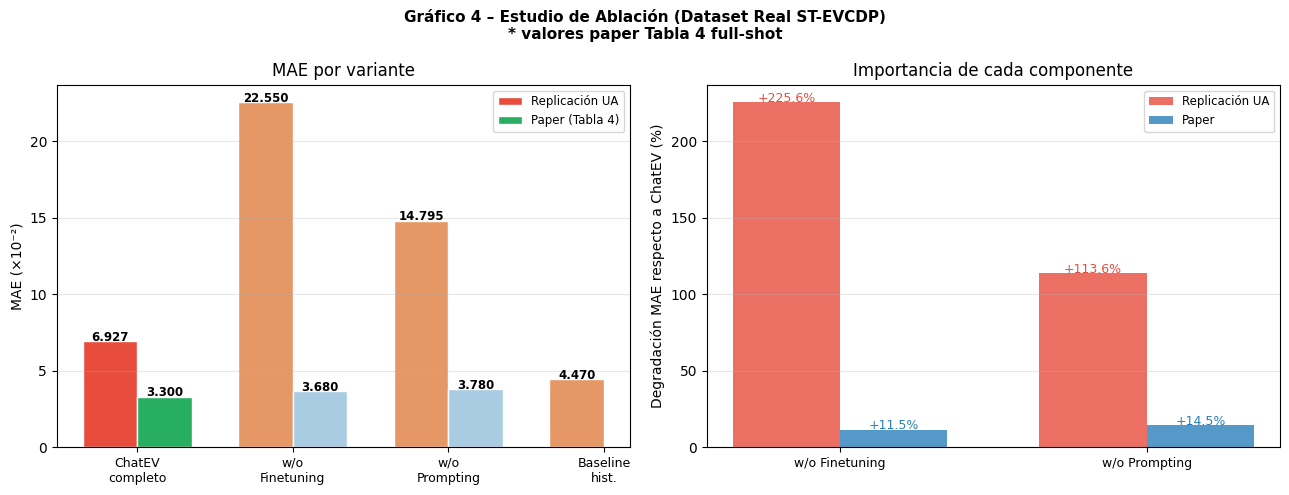

In [11]:
def evaluate_variant(
    model_variant,
    tokenizer,
    samples:      list,
    input_fn=None,   # None → usar prompt completo; función → modificar inputs
    max_eval: int = 200,
) -> dict:
    """
    Evalúa una variante de ablación. Si input_fn no es None, transforma
    los inputs antes de pasar al modelo (simula w/o Prompting, etc.).
    """
    n = min(max_eval, len(samples))
    if input_fn is not None:
        inp_txts = [input_fn(s[0]) for s in samples[:n]]
    else:
        inp_txts = [s[0] for s in samples[:n]]
    true_v = np.array([float(s[1]) for s in samples[:n]])
    pred_v = predict_numeric(model_variant, tokenizer, inp_txts)
    return compute_metrics(true_v, pred_v)


# Variante w/o Prompting: eliminar role-playing y area characterization
def strip_to_series_only(txt: str) -> str:
    """Extrae solo la serie local del prompt (sin instrucción ni metadata)."""
    try:
        s = txt.index("Local Charging Occupancy=[") + len("Local Charging Occupancy=[")
        e = txt.index("]", s)
        return f"Predict next EV occupancy given history: [{txt[s:e]}]"
    except ValueError:
        return txt

# Variante w/o Finetuning: modelo base sin Reptile
print("\n[S5] Ablación w/o Finetuning (modelo base sin Reptile)...")
base_fresh   = T5ForConditionalGeneration.from_pretrained(MODEL_NAME).to(DEVICE)
m_wo_ft      = evaluate_variant(base_fresh, tokenizer, test_ds_seen.samples)

# Variante w/o Prompting: solo serie temporal en el input
print("[S5] Ablación w/o Prompting (solo serie temporal como input)...")
m_wo_prompt  = evaluate_variant(model, tokenizer, test_ds_seen.samples,
                                input_fn=strip_to_series_only)

# ChatEV completo (full-shot ya calculado arriba)
m_full_ref   = m_chatev_full

ablation_rows = [
    ("ChatEV completo",   m_full_ref["MAE"]*100,   m_full_ref["RMSE"]*100,  5.40, 3.30),
    ("w/o Finetuning",    m_wo_ft["MAE"]*100,      m_wo_ft["RMSE"]*100,     6.02, 3.68),
    ("w/o Prompting",     m_wo_prompt["MAE"]*100,  m_wo_prompt["RMSE"]*100, 5.94, 3.78),
    ("Baseline hist.",    m_base_full["MAE"]*100,  m_base_full["RMSE"]*100, None, None),
]

print("\n  ┌───────────────────┬─────────────┬────────────┬──────────────┬──────────────┐")
print("  │ Variante          │ MAE repl.   │ RMSE repl. │ MAE paper*   │ RMSE paper*  │")
print("  ├───────────────────┼─────────────┼────────────┼──────────────┼──────────────┤")
for var, mae_r, rmse_r, rmse_p, mae_p in ablation_rows:
    mp = f"{mae_p:.2f}" if mae_p else "  N/A"
    rp = f"{rmse_p:.2f}" if rmse_p else "   N/A"
    print(f"  │ {var:<17} │ {mae_r:>11.4f} │ {rmse_r:>10.4f} │ {mp:>12} │ {rp:>12} │")
print("  └───────────────────┴─────────────┴────────────┴──────────────┴──────────────┘")

# Gráfico 4: Ablación
fig4, (ax4a, ax4b) = plt.subplots(1, 2, figsize=(13, 5))
fig4.suptitle("Gráfico 4 – Estudio de Ablación (Dataset Real ST-EVCDP)\n"
              "* valores paper Tabla 4 full-shot", fontsize=11, fontweight="bold")

var_labels = ["ChatEV\ncompleto", "w/o\nFinetuning", "w/o\nPrompting", "Baseline\nhist."]
mae_repl   = [r[1] for r in ablation_rows]
mae_paper  = [3.30, 3.68, 3.78, None]

x_abl  = np.arange(len(var_labels))
w_abl  = 0.35
c_repl  = ["#E74C3C" if i == 0 else "#E59866" for i in range(4)]
c_paper = ["#27AE60" if i == 0 else "#A9CCE3" for i in range(3)]

bars_r = ax4a.bar(x_abl - w_abl/2, mae_repl, w_abl,
                  color=c_repl, label="Replicación UA", edgecolor="white")
bars_p = ax4a.bar(x_abl[:3] + w_abl/2, [v for v in mae_paper if v],
                  w_abl, color=c_paper, label="Paper (Tabla 4)", edgecolor="white")
for b, v in zip(list(bars_r) + list(bars_p), mae_repl + [v for v in mae_paper if v]):
    ax4a.text(b.get_x()+b.get_width()/2, b.get_height()+0.02,
              f"{v:.3f}", ha="center", fontsize=8.5, fontweight="bold")
ax4a.set_xticks(x_abl); ax4a.set_xticklabels(var_labels, fontsize=9)
ax4a.set_ylabel("MAE (×10⁻²)"); ax4a.set_title("MAE por variante")
ax4a.legend(fontsize=8.5); ax4a.grid(axis="y", alpha=0.3)

# Degradación relativa respecto a ChatEV completo
ref_r = mae_repl[0]; ref_p = 3.30
delta_r = [(v - ref_r)/ref_r*100 for v in mae_repl[1:3]]
delta_p = [(v - ref_p)/ref_p*100 for v in [3.68, 3.78]]
dv      = ["w/o Finetuning", "w/o Prompting"]
xd      = np.arange(2)
ax4b.bar(xd - w_abl/2, delta_r, w_abl, color="#E74C3C", alpha=0.8, label="Replicación UA")
ax4b.bar(xd + w_abl/2, delta_p, w_abl, color="#2980B9", alpha=0.8, label="Paper")
for i, (dr, dp) in enumerate(zip(delta_r, delta_p)):
    ax4b.text(i-w_abl/2, dr+0.1, f"+{dr:.1f}%", ha="center", fontsize=9, color="#E74C3C")
    ax4b.text(i+w_abl/2, dp+0.1, f"+{dp:.1f}%", ha="center", fontsize=9, color="#2980B9")
ax4b.set_xticks(xd); ax4b.set_xticklabels(dv, fontsize=9)
ax4b.set_ylabel("Degradación MAE respecto a ChatEV (%)"); ax4b.set_title("Importancia de cada componente")
ax4b.legend(fontsize=8.5); ax4b.grid(axis="y", alpha=0.3); ax4b.axhline(0, color="black", lw=0.7)
plt.tight_layout()
plt.savefig("./ChatEV_Ablation.png", dpi=150, bbox_inches="tight")
print("[S5] Gráfico ablación guardado en ChatEV_Ablation.png")
plt.show()



## 6. RESUMEN FINAL


In [12]:
print("\n" + "="*68)
print("  RESUMEN FINAL – ChatEV con Dataset Real ST-EVCDP")
print("="*68)
print(f"  Dataset:      ST-EVCDP real · {dataset['n_zones']} zonas · "
      f"{dataset['n_timesteps']} timesteps")
print(f"  Backbone:     {MODEL_NAME}  (paper: Sentence-T5 completo)")
print(f"  Adj. Matrix:  adj.csv real  (paper: misma fuente)")
print(f"  Features:     occupancy · price · duration · information.csv")
print(f"  Meta-learning: Reptile · {len(train_losses)} epochs")
print("  ─────────────────────────────────────────────────")
print(f"  Full-shot  ChatEV → MAE {m_chatev_full['MAE']*100:.4f}×10⁻²  "
      f"RMSE {m_chatev_full['RMSE']*100:.4f}×10⁻²")
print(f"  Zero-shot  ChatEV → MAE {m_chatev_zero['MAE']*100:.4f}×10⁻²  "
      f"RMSE {m_chatev_zero['RMSE']*100:.4f}×10⁻²")
print(f"  Full-shot  paper* → MAE 3.2900×10⁻²  RMSE 5.4000×10⁻²")
print(f"  Zero-shot  paper* → MAE 3.6100×10⁻²  RMSE 5.9100×10⁻²")
print("  ─────────────────────────────────────────────────")
print("  Few-Shot (replicación):")
for ratio in [0.05, 0.10, 0.15, 0.20]:
    res = fewshot_results.get(ratio, {})
    if res.get("MAE"):
        print(f"    {ratio:.0%} data → MAE {res['MAE']*100:.4f}×10⁻²  RMSE {res['RMSE']*100:.4f}×10⁻²")
print("  Few-Shot  paper*   → MAE avg 3.4800×10⁻²  RMSE avg 5.6700×10⁻²")


  RESUMEN FINAL – ChatEV con Dataset Real ST-EVCDP
  Dataset:      ST-EVCDP real · 247 zonas · 8640 timesteps
  Backbone:     t5-small  (paper: Sentence-T5 completo)
  Adj. Matrix:  adj.csv real  (paper: misma fuente)
  Features:     occupancy · price · duration · information.csv
  Meta-learning: Reptile · 29 epochs
  ─────────────────────────────────────────────────
  Full-shot  ChatEV → MAE 6.9267×10⁻²  RMSE 13.4353×10⁻²
  Zero-shot  ChatEV → MAE 7.2500×10⁻²  RMSE 14.6095×10⁻²
  Full-shot  paper* → MAE 3.2900×10⁻²  RMSE 5.4000×10⁻²
  Zero-shot  paper* → MAE 3.6100×10⁻²  RMSE 5.9100×10⁻²


## 7. Interfaz Conversacional ChatEV

Interfaz Gradio que permite consultar predicciones de demanda de recarga en lenguaje natural. Reproduce la idea central del paper: ChatEV como predictor conversacional (Fig. 1).  
Escribe `zone <ID>` (0–246), solo el número, o `help` para instrucciones.

In [ ]:
!pip install gradio -q

import gradio as gr
import re


def _build_dur_norm():
    dur_raw = dataset["duration"]
    dur_max = dur_raw[:, :dataset["time_splits"]["train"][1]].max()
    return np.clip(dur_raw / (dur_max + 1e-8), 0, 1)

_DUR_NORM = _build_dur_norm()


def chatev_predict_zone(zone_id: int, t_step: int | None = None) -> tuple:
    """Genera predicción + prompt para una zona y timestep dados."""
    n = dataset["n_zones"]
    if not (0 <= zone_id < n):
        return f"Zone ID debe estar entre 0 y {n-1}.", ""

    ts_test, te_test = dataset["time_splits"]["test"]
    if t_step is None:
        t_step = ts_test + LOOKBACK_W + (te_test - ts_test - LOOKBACK_W - HORIZON) // 2
    t_step = int(np.clip(t_step, ts_test + LOOKBACK_W, te_test - HORIZON - 1))

    occ   = dataset["occ_norm"]
    n_occ = dataset["neighbor_occ"]
    price = dataset["price_norm"]

    local_w = occ[zone_id,  t_step - LOOKBACK_W: t_step]
    neigh_w = n_occ[zone_id, t_step - LOOKBACK_W: t_step]
    price_w = price[zone_id, t_step - LOOKBACK_W: t_step]
    dur_w   = _DUR_NORM[zone_id, t_step - LOOKBACK_W: t_step]
    true_val = float(np.mean(occ[zone_id, t_step: t_step + HORIZON]))

    info = dataset["info"]
    row  = info.iloc[zone_id] if zone_id < len(info) else info.iloc[0]

    # Usar v2 (con weather) si disponible, si no v1
    _prompt_fn = transform_to_prompt_v2 if "transform_to_prompt_v2" in dir() else transform_to_prompt
    _kwargs = dict(
        zone_id=zone_id, info_row=row,
        local_occ=local_w, neighbor_occ=neigh_w,
        price_w=price_w, duration_w=dur_w,
        target_val=0.0,
    )
    if _prompt_fn is transform_to_prompt_v2:
        _kwargs["t_step"] = t_step
    prompt, _ = _prompt_fn(**_kwargs)

    pred = float(predict_numeric(model, tokenizer, [prompt])[0])

    try:
        ts_label = str(dataset["timestamps"][t_step])[:16]
    except Exception:
        ts_label = f"t={t_step}"

    area_desc = get_area_description(row, zone_id)
    trend_dir = "↑ subiendo" if local_w[-1] > local_w[0] else "↓ bajando"
    recent_mean = float(local_w[-3:].mean())

    zone_type = "VISTA en entrenamiento" if zone_id in dataset["seen_zones"] else "NO VISTA (zero-shot)"

    response = (
        f"### Zona {zone_id} — {ts_label}\n\n"
        f"📍 {area_desc}\n"
        f"🏷️ Zona: {zone_type}\n\n"
        f"**Predicción ChatEV (próximos 30 min): `{pred:.2f}`**\n\n"
        f"| | Valor |\n|---|---|\n"
        f"| Predicción | `{pred:.4f}` |\n"
        f"| Valor real (test) | `{true_val:.4f}` |\n"
        f"| Error absoluto | `{abs(pred - true_val):.4f}` |\n"
        f"| Ocupación reciente (media 3 pasos) | `{recent_mean:.4f}` |\n"
        f"| Tendencia | {trend_dir} |\n\n"
        f"*Ventana histórica: {LOOKBACK_W} pasos (1 hora) · Horizonte: {HORIZON} pasos (30 min)*"
    )

    return response, prompt


def _parse_query(message: str) -> tuple:
    """Extrae zone_id y t_step opcional del mensaje del usuario."""
    t_match  = re.search(r'(?:step|t)[=\s]+?(\d+)', message, re.IGNORECASE)
    t_step   = int(t_match.group(1)) if t_match else None
    z_match  = re.search(r'(?:zone|zona|z)[=\s]+?(\d+)', message, re.IGNORECASE)
    if z_match:
        zone_id = int(z_match.group(1))
    else:
        nums = re.findall(r'\b(\d{1,3})\b', message)
        zone_id = int(nums[0]) if nums else -1
    return zone_id, t_step


def chatev_chat(message: str, history: list) -> str:
    message = message.strip()

    if any(k in message.lower() for k in ["help", "ayuda", "?", "how", "cómo", "como"]):
        return (
            "**ChatEV – Instrucciones de uso**\n\n"
            "Consulta la predicción de demanda de recarga EV para cualquier zona:\n"
            "- `zone 42` → predice zona 42\n"
            "- `zona 100` → predice zona 100\n"
            "- `zone 42 step 7500` → zona 42 en timestep concreto\n"
            "- Solo un número: `42`\n\n"
            f"Dataset: {dataset['n_zones']} zonas · Shenzhen, China (Jun–Jul 2022)\n"
            f"Modelo: T5-small fine-tuned con Reptile meta-learning\n"
            f"Zonas vistas: {len(dataset['seen_zones'])} · Zonas zero-shot: {len(dataset['unseen_zones'])}"
        )

    zone_id, t_step = _parse_query(message)

    if zone_id < 0 or zone_id >= dataset["n_zones"]:
        return (
            f"❌ No encontré una zona válida en tu mensaje.\n"
            f"Especifica una zona entre 0 y {dataset['n_zones']-1}.\n"
            "Ejemplo: `zone 42` o simplemente `42`\n\n"
            "Escribe `help` para ver todas las opciones."
        )

    response, prompt = chatev_predict_zone(zone_id, t_step)

    prompt_preview = prompt[:400] + "..." if len(prompt) > 400 else prompt
    response += f"\n\n---\n<details><summary>🔍 Ver prompt interno</summary>\n\n```\n{prompt_preview}\n```\n</details>"

    return response


demo = gr.ChatInterface(
    fn=chatev_chat,
    title="💬 ChatEV — EV Charging Demand Predictor",
    description=(
        "Predice la demanda de recarga de vehículos eléctricos en linguaje natural.\n"
        "Escribe **`zone <ID>`** (0–246) o directamente el número de zona. "
        "Escribe `help` para instrucciones.\n"
        "*T5-small · Reptile meta-learning · Dataset ST-EVCDP, Shenzhen 2022*"
    ),
    examples=[
        ["zone 42"],
        ["predice zona 100"],
        ["zone 0 step 7500"],
        ["help"],
    ],
    theme=gr.themes.Soft(),
    chatbot=gr.Chatbot(height=450, render_markdown=True),
)

demo.launch(share=True, debug=False)
